In [1]:
!pip install -q sentence-transformers faiss-cpu transformers datasets pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 33.9 MB/s eta 0:00:00


In [10]:
import numpy as np
import pandas as pd
import faiss
import torch
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from transformers import pipeline, AutoTokenizer, AutoModelForMaskedLM
from typing import List, Tuple, Dict
import warnings
warnings.filterwarnings("ignore")

CONFIG = {
    # Số lượng reviews dùng làm knowledge base (tăng để chính xác hơn)
    "kb_size": 2000,
    # Số ví dụ retrieve cho mỗi query (= K trong RAG)
    "top_k": 5,
    # Model embed (nhỏ, chạy tốt trên CPU Colab)
    "embed_model": "all-MiniLM-L6-v2",
    # LM để fill-mask (tuning-free prompting)
    "lm_model": "distilbert-base-uncased",
    # Số reviews dùng để evaluate
    "eval_size": 100,
    # Seed để tái hiện kết quả
    "seed": 42,
}

print("✓ Config loaded")
print(f"  KB size     : {CONFIG['kb_size']} reviews")
print(f"  Top-K       : {CONFIG['top_k']} retrieved examples")
print(f"  Embed model : {CONFIG['embed_model']}")
print(f"  LM model    : {CONFIG['lm_model']}")

✓ Config loaded
  KB size     : 2000 reviews
  Top-K       : 5 retrieved examples
  Embed model : all-MiniLM-L6-v2
  LM model    : distilbert-base-uncased


In [11]:
def load_imdb_sample(kb_size: int, eval_size: int, seed: int):
    """
    Load IMDB từ HuggingFace datasets.
    Tách rõ: knowledge base (train) và evaluation set (test).
    """
    print("Loading IMDB dataset...")
    dataset = load_dataset("imdb")

    # Knowledge base: lấy từ train split
    train_df = dataset["train"].to_pandas()
    kb_df = train_df.sample(n=kb_size, random_state=seed).reset_index(drop=True)

    # Evaluation: lấy từ test split
    test_df = dataset["test"].to_pandas()
    eval_df = test_df.sample(n=eval_size, random_state=seed).reset_index(drop=True)

    # Chuyển nhãn số → text (0=negative, 1=positive)
    label_map = {0: "negative", 1: "positive"}
    kb_df["label_text"] = kb_df["label"].map(label_map)
    eval_df["label_text"] = eval_df["label"].map(label_map)

    # Truncate text để tránh quá dài
    kb_df["text_short"] = kb_df["text"].str[:300]
    eval_df["text_short"] = eval_df["text"].str[:300]

    print(f"✓ Knowledge base : {len(kb_df)} reviews")
    print(f"  Positive: {kb_df['label'].sum()} | Negative: {(kb_df['label']==0).sum()}")
    print(f"✓ Eval set       : {len(eval_df)} reviews")
    return kb_df, eval_df


def build_faiss_index(kb_df: pd.DataFrame, embed_model_name: str):
    """
    Embed toàn bộ knowledge base và build FAISS index.
    Đây là Phase 1 (offline indexing) trong kiến trúc RAG.
    """
    print(f"\nBuilding FAISS index with {embed_model_name}...")
    embed_model = SentenceTransformer(embed_model_name)

    # Embed tất cả reviews trong KB
    texts = kb_df["text_short"].tolist()
    embeddings = embed_model.encode(
        texts,
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True
    )
    embeddings = embeddings.astype("float32")

    # Normalize để cosine similarity = dot product
    faiss.normalize_L2(embeddings)

    # Build index — dùng IndexFlatIP (inner product = cosine sau normalize)
    dim = embeddings.shape[1]
    index = faiss.IndexFlatIP(dim)
    index.add(embeddings)

    print(f"✓ Index built: {index.ntotal} vectors, dim={dim}")
    return embed_model, index, embeddings


def retrieve_similar(
    query: str,
    embed_model: SentenceTransformer,
    index: faiss.Index,
    kb_df: pd.DataFrame,
    top_k: int
) -> List[Dict]:
    """
    Phase 2 (online): Embed query → FAISS search → trả về top-K examples.
    Đây là bước Retrieval trong RAG, tương đương Prompt Augmentation
    (Liu et al. Section 5.2).
    """
    query_vec = embed_model.encode([query[:300]], convert_to_numpy=True).astype("float32")
    faiss.normalize_L2(query_vec)

    scores, indices = index.search(query_vec, top_k)

    results = []
    for score, idx in zip(scores[0], indices[0]):
        results.append({
            "text": kb_df.iloc[idx]["text_short"],
            "label": kb_df.iloc[idx]["label_text"],
            "score": float(score),
        })
    return results


# ── Load data và build index ──
kb_df, eval_df = load_imdb_sample(
    CONFIG["kb_size"], CONFIG["eval_size"], CONFIG["seed"]
)
embed_model, faiss_index, _ = build_faiss_index(kb_df, CONFIG["embed_model"])

Loading IMDB dataset...
✓ Knowledge base : 2000 reviews
  Positive: 960 | Negative: 1040
✓ Eval set       : 100 reviews

Building FAISS index with all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

✓ Index built: 2000 vectors, dim=384


In [12]:
TEMPLATES = {

    # ── Template 1: Cloze Prompt ──────────────────────────
    # Liu et al. Section 3.1: "[Z] ở giữa câu"
    # Answer space Z = {"great", "terrible"} — Constrained (Section 4.2.1)
    "cloze_simple": {
        "name": "Cloze — Simple",
        "type": "cloze",
        "description": "Cloze prompt đơn giản, answer ở giữa câu",
        "paper_ref": "Liu et al. §3.1 + §4.2.1 Constrained Space",
        "build": lambda query, examples: (
            f"{query[:200]} Overall, it was a [MASK] movie.",
            ["great", "terrible"]
        ),
    },

    # ── Template 2: Cloze Prompt với RAG context ──────────
    # Kết hợp Cloze + Prompt Augmentation (Section 5.2)
    # Các retrieved examples làm "answered prompts"
    "cloze_rag": {
        "name": "Cloze + RAG (In-context)",
        "type": "cloze",
        "description": "Cloze prompt được augment bằng retrieved examples",
        "paper_ref": "Liu et al. §3.1 + §5.2 Prompt Augmentation",
        "build": lambda query, examples: (
            " ".join([
                f"{ex['text'][:120]} Overall, it was a {'great' if ex['label']=='positive' else 'terrible'} movie."
                for ex in examples[:2]
            ]) + f" {query[:150]} Overall, it was a [MASK] movie.",
            ["great", "terrible"]
        ),
    },

    # ── Template 3: Prefix Prompt ─────────────────────────
    # Liu et al. Section 3.1: "[Z] ở cuối — prefix style"
    # Phù hợp hơn với autoregressive LM nhưng dùng fill-mask để demo
    "prefix_simple": {
        "name": "Prefix — Simple",
        "type": "prefix",
        "description": "Prefix prompt — label ở cuối dưới dạng fill-mask",
        "paper_ref": "Liu et al. §3.1 Prefix Prompt",
        "build": lambda query, examples: (
            f"Review: {query[:200]} Sentiment: [MASK].",
            ["positive", "negative"]
        ),
    },

    # ── Template 4: Prefix Prompt với RAG context ─────────
    # Min et al. §3.1 Learning from Demonstrations
    # + Liu et al. §5.2 Prompt Augmentation
    "prefix_rag": {
        "name": "Prefix + RAG (Few-shot)",
        "type": "prefix",
        "description": "Prefix prompt few-shot với retrieved demonstrations",
        "paper_ref": "Min et al. §3.1 + Liu et al. §5.2",
        "build": lambda query, examples: (
            " ".join([
                f"Review: {ex['text'][:100]} Sentiment: {ex['label']}."
                for ex in examples[:2]
            ]) + f" Review: {query[:150]} Sentiment: [MASK].",
            ["positive", "negative"]
        ),
    },

    # ── Template 5: PET-style (Schick & Schütze 2021) ─────
    # Manual template engineering theo phong cách PET
    # Constrained answer space nhỏ
    "pet_style": {
        "name": "PET-style Manual",
        "type": "cloze",
        "description": "Template theo phong cách PET với ngôn ngữ tự nhiên hơn",
        "paper_ref": "Liu et al. §3.2 Manual Template + §4.2.1",
        "build": lambda query, examples: (
            f"{query[:200]} All in all, the movie was [MASK].",
            ["good", "bad"]
        ),
    },
}

print(f"✓ {len(TEMPLATES)} prompt templates defined:")
for key, t in TEMPLATES.items():
    print(f"  [{key}] {t['name']} — {t['paper_ref']}")

✓ 5 prompt templates defined:
  [cloze_simple] Cloze — Simple — Liu et al. §3.1 + §4.2.1 Constrained Space
  [cloze_rag] Cloze + RAG (In-context) — Liu et al. §3.1 + §5.2 Prompt Augmentation
  [prefix_simple] Prefix — Simple — Liu et al. §3.1 Prefix Prompt
  [prefix_rag] Prefix + RAG (Few-shot) — Min et al. §3.1 + Liu et al. §5.2
  [pet_style] PET-style Manual — Liu et al. §3.2 Manual Template + §4.2.1


In [13]:
def load_lm(model_name: str):
    """Load masked LM để thực hiện tuning-free prompting."""
    print(f"\nLoading LM: {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForMaskedLM.from_pretrained(model_name)
    model.eval()
    print(f"✓ LM loaded ({sum(p.numel() for p in model.parameters())/1e6:.0f}M params)")
    return tokenizer, model


def predict_sentiment(
    prompt_text: str,
    answer_space: List[str],
    tokenizer,
    model,
    label_map: Dict[str, str] = None
) -> Tuple[str, Dict[str, float]]:
    """
    Tuning-free prompting: điền [MASK] bằng LM, chọn token trong answer_space.
    Đây là Answer Search (Liu et al. §2.2.2) + Answer Mapping (§2.2.3).

    Trả về:
        predicted_label: "positive" hoặc "negative"
        scores: xác suất của từng answer trong answer_space
    """
    # Mặc định: map answer token → sentiment label
    if label_map is None:
        label_map = {
            "great": "positive", "good": "positive", "positive": "positive",
            "wonderful": "positive", "excellent": "positive",
            "terrible": "negative", "bad": "negative", "negative": "negative",
            "awful": "negative", "horrible": "negative",
        }

    # Truncate prompt nếu quá dài (BERT max 512 tokens)
    inputs = tokenizer(
        prompt_text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    # Tìm vị trí [MASK]
    mask_pos = (inputs["input_ids"] == tokenizer.mask_token_id).nonzero(as_tuple=True)
    if len(mask_pos[0]) == 0:
        return "unknown", {}

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits  # shape: [1, seq_len, vocab_size]

    # Lấy logit tại vị trí [MASK] đầu tiên
    mask_token_logits = logits[0, mask_pos[1][0], :]
    probs = torch.softmax(mask_token_logits, dim=-1)

    # Chỉ xét các token trong answer_space (Constrained Space - §4.2.1)
    scores = {}
    for answer in answer_space:
        token_ids = tokenizer.encode(answer, add_special_tokens=False)
        if len(token_ids) == 1:
            scores[answer] = probs[token_ids[0]].item()
        else:
            # Multi-token: lấy trung bình xác suất
            scores[answer] = np.mean([probs[t].item() for t in token_ids])

    # Answer Mapping: token → sentiment label
    best_answer = max(scores, key=scores.get)
    predicted_label = label_map.get(best_answer, best_answer)

    return predicted_label, scores


def run_single(query: str, template_key: str, tokenizer, model) -> Dict:
    """Chạy RAG inference cho một review với một template."""
    template = TEMPLATES[template_key]

    # Retrieve similar examples
    examples = retrieve_similar(
        query, embed_model, faiss_index, kb_df, CONFIG["top_k"]
    )

    # Build prompt
    prompt_text, answer_space = template["build"](query, examples)

    # Predict
    pred_label, scores = predict_sentiment(prompt_text, answer_space, tokenizer, model)

    return {
        "template": template["name"],
        "prompt_preview": prompt_text[:200] + "...",
        "retrieved_examples": [(ex["text"][:80], ex["label"], round(ex["score"], 3))
                                for ex in examples],
        "answer_space": answer_space,
        "scores": {k: round(v, 4) for k, v in scores.items()},
        "prediction": pred_label,
    }


# ── Load LM ──
tokenizer, lm_model = load_lm(CONFIG["lm_model"])


Loading LM: distilbert-base-uncased...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

✓ LM loaded (67M params)


In [14]:
demo_review = """
This movie exceeded all my expectations. The acting was superb,
the plot was engaging from start to finish, and the cinematography
was absolutely breathtaking. I would highly recommend it to anyone.
"""

print("=" * 60)
print("DEMO: Single Review Prediction")
print("=" * 60)
print(f"Review: {demo_review.strip()[:100]}...")
print()

for template_key in TEMPLATES:
    result = run_single(demo_review, template_key, tokenizer, lm_model)
    print(f"[{result['template']}]")
    print(f"  Prediction : {result['prediction'].upper()}")
    print(f"  Scores     : {result['scores']}")
    print(f"  Retrieved  : {[(r[1], r[2]) for r in result['retrieved_examples']]}")
    print()

DEMO: Single Review Prediction
Review: This movie exceeded all my expectations. The acting was superb,
the plot was engaging from start to ...

[Cloze — Simple]
  Prediction : POSITIVE
  Scores     : {'great': 0.0531, 'terrible': 0.002}
  Retrieved  : [('positive', 0.774), ('positive', 0.744), ('positive', 0.736), ('positive', 0.729), ('negative', 0.726)]

[Cloze + RAG (In-context)]
  Prediction : POSITIVE
  Scores     : {'great': 0.1376, 'terrible': 0.0025}
  Retrieved  : [('positive', 0.774), ('positive', 0.744), ('positive', 0.736), ('positive', 0.729), ('negative', 0.726)]

[Prefix — Simple]
  Prediction : POSITIVE
  Scores     : {'positive': 0.0151, 'negative': 0.0074}
  Retrieved  : [('positive', 0.774), ('positive', 0.744), ('positive', 0.736), ('positive', 0.729), ('negative', 0.726)]

[Prefix + RAG (Few-shot)]
  Prediction : POSITIVE
  Scores     : {'positive': 0.49, 'negative': 0.032}
  Retrieved  : [('positive', 0.774), ('positive', 0.744), ('positive', 0.736), ('positive', 

In [15]:
def evaluate_all_templates(eval_df: pd.DataFrame, tokenizer, model) -> pd.DataFrame:
    """
    Chạy tất cả templates trên eval_df.
    Tính accuracy cho từng template để so sánh.
    """
    results = {key: {"correct": 0, "total": 0, "predictions": []}
               for key in TEMPLATES}

    print(f"Evaluating {len(eval_df)} reviews × {len(TEMPLATES)} templates...")
    print("(Có thể mất 5–10 phút trên Colab CPU)")

    for i, row in eval_df.iterrows():
        if i % 20 == 0:
            print(f"  Progress: {i}/{len(eval_df)}")

        true_label = row["label_text"]

        for template_key in TEMPLATES:
            result = run_single(row["text"], template_key, tokenizer, lm_model)
            pred = result["prediction"]

            results[template_key]["total"] += 1
            results[template_key]["predictions"].append(pred)
            if pred == true_label:
                results[template_key]["correct"] += 1

    # Tổng hợp thành DataFrame
    summary = []
    for key, data in results.items():
        t = TEMPLATES[key]
        acc = data["correct"] / data["total"] * 100
        summary.append({
            "Template": t["name"],
            "Type": t["type"],
            "Accuracy (%)": round(acc, 1),
            "Correct": data["correct"],
            "Total": data["total"],
            "Paper Ref": t["paper_ref"],
            "Description": t["description"],
        })

    return pd.DataFrame(summary).sort_values("Accuracy (%)", ascending=False)


# Chạy evaluation
eval_results = evaluate_all_templates(eval_df, tokenizer, lm_model)

print("\n" + "=" * 60)
print("RESULTS: Template Comparison on IMDB")
print("=" * 60)
print(eval_results[["Template", "Type", "Accuracy (%)", "Paper Ref"]].to_string(index=False))

Evaluating 100 reviews × 5 templates...
(Có thể mất 5–10 phút trên Colab CPU)
  Progress: 0/100
  Progress: 20/100
  Progress: 40/100
  Progress: 60/100
  Progress: 80/100

RESULTS: Template Comparison on IMDB
                Template   Type  Accuracy (%)                                  Paper Ref
          Cloze — Simple  cloze          73.0 Liu et al. §3.1 + §4.2.1 Constrained Space
        PET-style Manual  cloze          71.0   Liu et al. §3.2 Manual Template + §4.2.1
         Prefix — Simple prefix          64.0              Liu et al. §3.1 Prefix Prompt
 Prefix + RAG (Few-shot) prefix          63.0          Min et al. §3.1 + Liu et al. §5.2
Cloze + RAG (In-context)  cloze          56.0 Liu et al. §3.1 + §5.2 Prompt Augmentation


✓ Saved: rag_sentiment_results.png


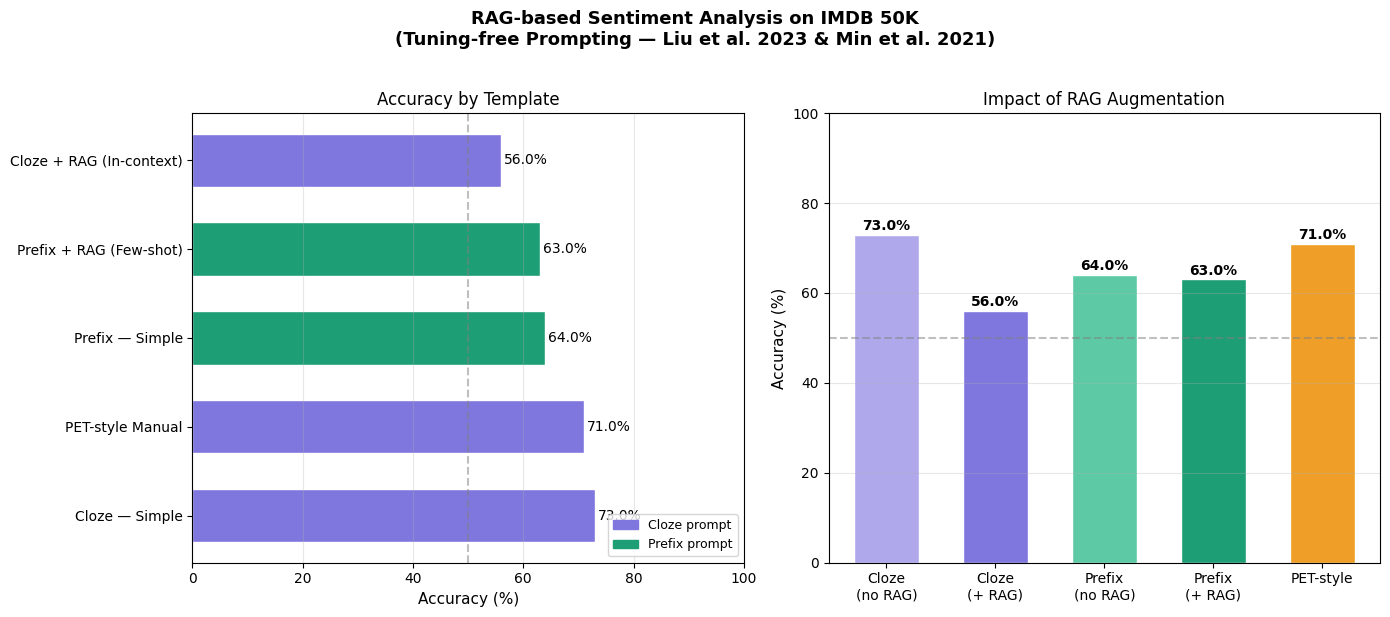

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_results_for_slide(eval_results: pd.DataFrame):
    """
    Tạo 2 biểu đồ sẵn sàng để đưa vào slide thuyết trình:
    1. Bar chart so sánh accuracy các templates
    2. Grouped bar chart: RAG vs no-RAG
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(
        "RAG-based Sentiment Analysis on IMDB 50K\n(Tuning-free Prompting — Liu et al. 2023 & Min et al. 2021)",
        fontsize=13, fontweight="bold", y=1.02
    )

    # ── Plot 1: Accuracy bar chart ──
    ax1 = axes[0]
    colors = {
        "cloze": "#7F77DD",
        "prefix": "#1D9E75",
    }
    bar_colors = [colors[t] for t in eval_results["Type"]]
    bars = ax1.barh(
        eval_results["Template"],
        eval_results["Accuracy (%)"],
        color=bar_colors,
        edgecolor="white",
        height=0.6
    )
    ax1.set_xlabel("Accuracy (%)", fontsize=11)
    ax1.set_title("Accuracy by Template", fontsize=12)
    ax1.set_xlim(0, 100)
    ax1.axvline(50, color="gray", linestyle="--", alpha=0.5, label="Random baseline")

    # Value labels
    for bar, val in zip(bars, eval_results["Accuracy (%)"]):
        ax1.text(
            bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=10
        )

    # Legend
    patch_cloze = mpatches.Patch(color="#7F77DD", label="Cloze prompt")
    patch_prefix = mpatches.Patch(color="#1D9E75", label="Prefix prompt")
    ax1.legend(handles=[patch_cloze, patch_prefix], loc="lower right", fontsize=9)
    ax1.grid(axis="x", alpha=0.3)

    # ── Plot 2: RAG vs no-RAG grouped ──
    ax2 = axes[1]
    rag_data = {
        "Cloze\n(no RAG)": eval_results.loc[eval_results["Template"].str.contains("Simple.*Cloze|Cloze.*Simple"), "Accuracy (%)"].values,
        "Cloze\n(+ RAG)": eval_results.loc[eval_results["Template"].str.contains("RAG.*Cloze|Cloze.*RAG"), "Accuracy (%)"].values,
        "Prefix\n(no RAG)": eval_results.loc[eval_results["Template"].str.contains("Simple.*Prefix|Prefix.*Simple"), "Accuracy (%)"].values,
        "Prefix\n(+ RAG)": eval_results.loc[eval_results["Template"].str.contains("RAG.*Prefix|Prefix.*RAG|Few-shot"), "Accuracy (%)"].values,
        "PET-style": eval_results.loc[eval_results["Template"].str.contains("PET"), "Accuracy (%)"].values,
    }

    labels = list(rag_data.keys())
    values = [v[0] if len(v) > 0 else 0 for v in rag_data.values()]
    bar_cols2 = ["#AFA9EC", "#7F77DD", "#5DCAA5", "#1D9E75", "#EF9F27"]

    bars2 = ax2.bar(labels, values, color=bar_cols2, edgecolor="white", width=0.6)
    ax2.set_ylabel("Accuracy (%)", fontsize=11)
    ax2.set_title("Impact of RAG Augmentation", fontsize=12)
    ax2.set_ylim(0, 100)
    ax2.axhline(50, color="gray", linestyle="--", alpha=0.5)

    for bar, val in zip(bars2, values):
        ax2.text(
            bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val:.1f}%", ha="center", fontsize=10, fontweight="bold"
        )
    ax2.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig("rag_sentiment_results.png", dpi=150, bbox_inches="tight")
    print("✓ Saved: rag_sentiment_results.png")
    plt.show()


plot_results_for_slide(eval_results)

In [17]:
def print_slide_insights(eval_results: pd.DataFrame):
    """In ra các insight chính để đưa vào slide thuyết trình."""
    best = eval_results.iloc[0]
    worst = eval_results.iloc[-1]

    # Tìm RAG vs no-RAG delta
    rag_rows = eval_results[eval_results["Template"].str.contains("RAG")]
    norag_rows = eval_results[~eval_results["Template"].str.contains("RAG")]

    print("\n" + "=" * 60)
    print("KEY INSIGHTS FOR SLIDE")
    print("=" * 60)
    print(f"\n1. Best template  : {best['Template']} → {best['Accuracy (%)']}%")
    print(f"   Paper ref       : {best['Paper Ref']}")
    print(f"\n2. Worst template : {worst['Template']} → {worst['Accuracy (%)']}%")
    print(f"   Gap vs best     : {best['Accuracy (%)'] - worst['Accuracy (%)']:.1f}%")

    if len(rag_rows) > 0 and len(norag_rows) > 0:
        avg_rag = rag_rows["Accuracy (%)"].mean()
        avg_norag = norag_rows["Accuracy (%)"].mean()
        delta = avg_rag - avg_norag
        print(f"\n3. RAG augmentation impact:")
        print(f"   Avg with RAG    : {avg_rag:.1f}%")
        print(f"   Avg without RAG : {avg_norag:.1f}%")
        print(f"   Delta           : {delta:+.1f}% ({'improvement' if delta > 0 else 'degradation'})")

    print(f"\n4. Liên kết lý thuyết:")
    print(f"   - Template shape (Cloze vs Prefix): Liu et al. §3.1")
    print(f"   - Manual Template Engineering      : Liu et al. §3.2")
    print(f"   - Prompt Augmentation (RAG)        : Liu et al. §5.2")
    print(f"   - Tuning-free Prompting            : Liu et al. §6.2.2")
    print(f"   - In-context Learning              : Min et al. §3.1")
    print(f"   - Constrained Answer Space         : Liu et al. §4.2.1")


print_slide_insights(eval_results)


KEY INSIGHTS FOR SLIDE

1. Best template  : Cloze — Simple → 73.0%
   Paper ref       : Liu et al. §3.1 + §4.2.1 Constrained Space

2. Worst template : Cloze + RAG (In-context) → 56.0%
   Gap vs best     : 17.0%

3. RAG augmentation impact:
   Avg with RAG    : 59.5%
   Avg without RAG : 69.3%
   Delta           : -9.8% (degradation)

4. Liên kết lý thuyết:
   - Template shape (Cloze vs Prefix): Liu et al. §3.1
   - Manual Template Engineering      : Liu et al. §3.2
   - Prompt Augmentation (RAG)        : Liu et al. §5.2
   - Tuning-free Prompting            : Liu et al. §6.2.2
   - In-context Learning              : Min et al. §3.1
   - Constrained Answer Space         : Liu et al. §4.2.1
